<a href="https://colab.research.google.com/github/Shithijms/4exp/blob/main/DeepLearningExperiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Exp

#1.Design and implement a deep feedforward neural network to learn the XOR function using gradient-based learning and hidden units.


In [11]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

model = Sequential()
model.add(Input(shape=(2,)))
model.add(Dense(4, activation='tanh')) # Changed to 4 units and 'tanh' activation for stable learning
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer=Adam(learning_rate=0.1), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X,y,epochs=1000,verbose=0)
loss,accuracy = model.evaluate(X,y)
print(f'Accuracy: {accuracy*100:.2f}%')
predictions = model.predict(X)
predictions = (predictions > 0.5).astype(int)
print(f'Predictions')
for i, prediction in enumerate(predictions):
  print(f'Input:{X[i]}-Predicted Output:{prediction[0]}-True Output:{y[i]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 1.0000 - loss: 5.9797e-05
Accuracy: 100.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predictions
Input:[0 0]-Predicted Output:0-True Output:0
Input:[0 1]-Predicted Output:1-True Output:1
Input:[1 0]-Predicted Output:1-True Output:1
Input:[1 1]-Predicted Output:0-True Output:0


#2. Implement regularization techniques in deep learning models using parameter norm penalties, dataset augmentation, and noise robustness for improved generalization.

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import numpy as np

(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255
x_train = np.expand_dims(x_train,-1)
y_train = tf.keras.utils.to_categorical(y_train, 10)

noise = 0.05*np.random.normal(size=x_train.shape)
x_train = np.clip(x_train+noise,0,1)

datagen = keras.preprocessing.image.ImageDataGenerator(
rotation_range=10,
width_shift_range=0.1,
height_shift_range=0.1,
validation_split=0.2 # 20% validation
)
datagen.fit(x_train)

model = keras.Sequential([
layers.Flatten(input_shape=(28,28,1)),
layers.Dense(256, activation='relu',
kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4)),
layers.Dropout(0.5),
layers.Dense(128, activation='relu',
kernel_regularizer=regularizers.l2(1e-4)),
layers.Dropout(0.3),
layers.Dense(10, activation='softmax')
])
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    datagen.flow(x_train, y_train, batch_size=128,subset='validation'),
    epochs=50,
    callbacks=[early_stop]
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.4678 - loss: 1.6898
Epoch 2/50
 3/94 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6194 - loss: 1.3088

/usr/local/lib/python3.13/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.6936 - loss: 1.0750
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.7649 - loss: 0.8643
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8012 - loss: 0.7494
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8301 - loss: 0.6759
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 59ms/step - accuracy: 0.8454 - loss: 0.6249
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8508 - loss: 0.5982
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8601 - loss: 0.5720
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.8636 - loss: 0.5591
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.8734 - loss: 0.5312
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8837 - loss: 0.5133
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.8850 - loss: 0.5024
Epoch 13/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8843 - 

#3.Implement and compare different optimization algorithms (SGD, Momentum, Adam) for training a simple neural network on a toy dataset.

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


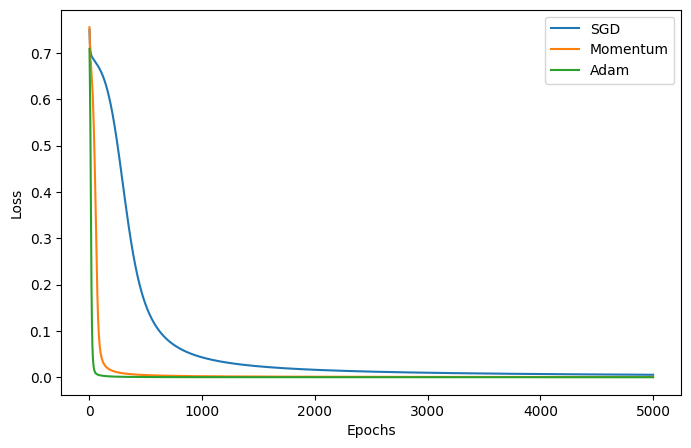

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers, losses
import numpy as np
import matplotlib.pyplot as plt
# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
# --- Toy dataset: XOR Problem ---
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y = np.array([[0],[1],[1],[0]], dtype=np.float32)

def create_model():
  model = keras.Sequential([
    layers.Dense(4, input_dim=2,activation='tanh'),
    layers.Dense(1, activation='sigmoid')
  ])
  return model
def train_model(optimizer_name,X,y,epochs=5000,lr=0.1):
  model = create_model()
  # Choose optimizer
  if optimizer_name == 'SGD':
    optimizer = optimizers.SGD(learning_rate=lr)
  elif optimizer_name == 'Momentum':
    optimizer = optimizers.SGD(learning_rate=lr, momentum=0.9)
  elif optimizer_name == 'Adam':
    optimizer = optimizers.Adam(learning_rate=lr)
  else:
    raise ValueError(f'Unknown optimizer: {optimizer_name}')
  # Compile model
  model.compile(optimizer=optimizer, loss=losses.BinaryCrossentropy())
  # Train model
  history = model.fit(X, y, epochs=epochs, verbose=0)
  return history.history['loss']

plt.figure(figsize=(8,5))
plt.plot(train_model('SGD',X,y),label='SGD')
plt.plot(train_model('Momentum',X,y),label='Momentum')
plt.plot(train_model('Adam',X,y),label='Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#4. Build a CNN on MNIST dataset to demonstrate convolution, pooling, and classification.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 67ms/step - accuracy: 0.9446 - loss: 0.1862 - val_accuracy: 0.9792 - val_loss: 0.0720
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 55s 66ms/step - accuracy: 0.9822 - loss: 0.0559 - val_accuracy: 0.9833 - val_loss: 0.0586
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 55s 65ms/step - accuracy: 0.9881 - loss: 0.0382 - val_accuracy: 0.9852 - val_loss: 0.0516
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.9847 - val_loss: 0.0575
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.9934 - loss: 0.0211 - val_accuracy: 0.9820 - val_loss: 0.0645
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9828 - loss: 0.0536
Test accuracy: 0.9828


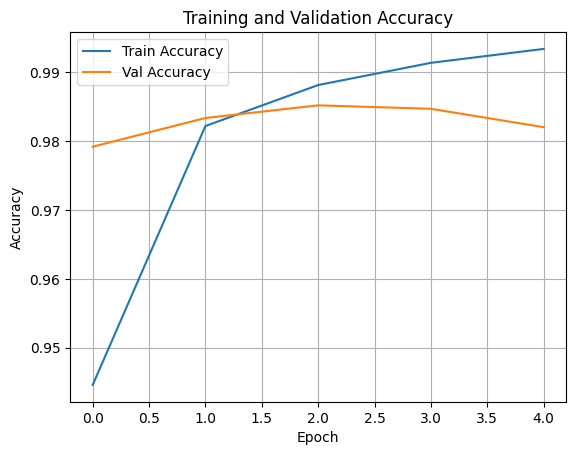

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1. Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()
# Reshape data to fit the model (add channel dimension)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255
# One-hot encode the labels
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# 2. Build the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # Convolution
    layers.MaxPooling2D((2, 2)), # Pooling
    layers.Conv2D(64, (3, 3), activation='relu'), # Another conv layer
    layers.MaxPooling2D((2, 2)), # Another pooling
    layers.Flatten(), # Flatten before Dense
    layers.Dense(64, activation='relu'), # Fully connected
    layers.Dense(10, activation='softmax') # Output layer
])

# 3. Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)

# 5. Evaluate the model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

# 6. Plot training history (optional)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()




# 5. Implement an LSTM-based RNN for text classification to demonstrate sequence      modeling, unfolding computational graphs, and handling long-term dependencies.


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Training...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 163ms/step - accuracy: 0.5604 - loss: 0.6742 - val_accuracy: 0.6242 - val_loss: 0.6346
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.6501 - loss: 0.6395 - val_accuracy: 0.5680 - val_loss: 0.6550
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.7042 - loss: 0.5752 - val_accuracy: 0.7924 - val_loss: 0.4934
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.8034 - loss: 0.4733 - val_accuracy: 0.7996 - val_loss: 0.5042
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step - accuracy: 0.8347 - loss: 0.4220 - val_accuracy: 0.7986 - val_loss: 0.4930

Evaluating on test set...
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.8017 - loss: 0.4847

 Test Accuracy: 0.8017


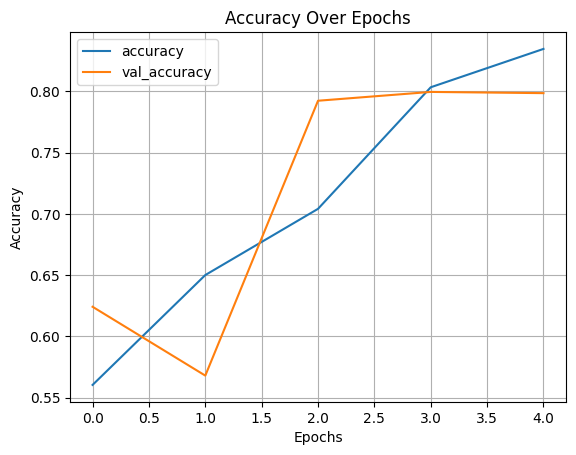

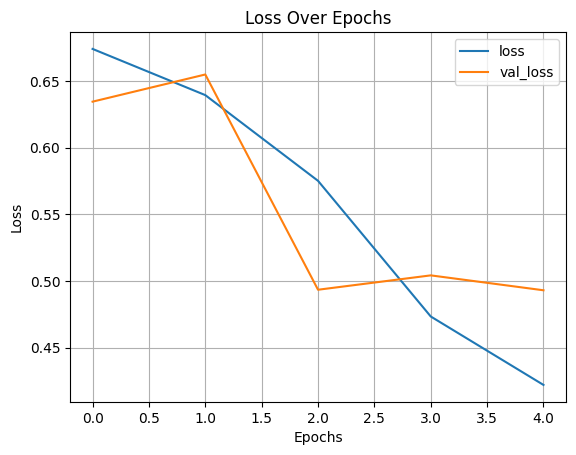

In [13]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
import matplotlib.pyplot as plt

# ----------------------------
# 1. Load and Preprocess Data
# ----------------------------
vocab_size = 10000
max_sequence_length = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=max_sequence_length, padding='post')
x_test = pad_sequences(x_test, maxlen=max_sequence_length, padding='post')

# ----------------------------
# 2. Build the LSTM RNN Model
# ----------------------------
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=64))
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

# ----------------------------
# 3. Compile the Model
# ----------------------------
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----------------------------
# 4. Train the Model
# ----------------------------
print("\nTraining...")
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# ----------------------------
# 5. Evaluate the Model
# ----------------------------
print("\nEvaluating on test set...")
loss, accuracy = model.evaluate(x_test, y_test)
print(f"\n Test Accuracy: {accuracy:.4f}")

# ----------------------------
# 6. Plot Accuracy and Loss Graphs
# ----------------------------
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_' + string])
    plt.xlabel("Epochs")
    plt.ylabel(string.capitalize())
    plt.title(f"{string.capitalize()} Over Epochs")
    plt.legend([string, 'val_' + string])
    plt.grid(True)
    plt.show()

# Plot training vs validation accuracy
plot_graphs(history, "accuracy")
# Plot training vs validation loss
plot_graphs(history, "loss")

In [ ]:
# 6. Construct a Bidirectional RNN and compare its performance with a standard RNN on sequence prediction tasks.
import tensorflow as tf
import numpy as np

# Synthetic dataset: predict next number in a sequence
seq_length = 10
num_samples = 1000
X = []
y = []
for _ in range(num_samples):
    start = np.random.randint(0, 100)
    seq = np.arange(start, start + seq_length)
    X.append(seq[:-1])
    y.append(seq[1:])
X = np.array(X, dtype=np.float32)[..., np.newaxis] # (batch, seq_len-1, 1)
y = np.array(y, dtype=np.float32)[..., np.newaxis] # (batch, seq_len-1, 1)

# Define Simple RNN model
def build_simple_rnn(input_size=1, hidden_size=32, output_size=1):
    model = tf.keras.Sequential([
        tf.keras.layers.SimpleRNN(hidden_size, return_sequences=True, input_shape=(seq_length - 1, input_size)),
        tf.keras.layers.Dense(output_size)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse')
    return model

# Define Bidirectional RNN model
def build_birnn(input_size=1, hidden_size=32, output_size=1):
    model = tf.keras.Sequential([
        tf.keras.layers.Bidirectional(
            tf.keras.layers.SimpleRNN(hidden_size, return_sequences=True),
            input_shape=(seq_length - 1, input_size)
        ),
        tf.keras.layers.Dense(output_size)
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(0.01), loss='mse')
    return model

# Train models
def train_model(model, X, y, epochs=50):
    history = model.fit(X, y, epochs=epochs, verbose=0)
    return history.history['loss'][-1]

rnn_model = build_simple_rnn()
birnn_model = build_birnn()
rnn_loss = train_model(rnn_model, X, y)
birnn_loss = train_model(birnn_model, X, y)
print(f"Final Loss (RNN): {rnn_loss:.4f}")
print(f"Final Loss (BiRNN): {birnn_loss:.4f}")

In [ ]:
# 7. Implement an encoder-decoder architecture with LSTMs for sequence-to-sequence learning.
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

# === Configuration ===
num_samples = 1000 # number of training samples
timesteps = 5 # sequence length
input_dim = 1 # features per timestep
latent_dim = 32 # hidden size of LSTM

# === Create toy data ===
X = np.random.rand(num_samples, timesteps, input_dim)
Y = np.flip(X, axis=1) # reversed sequences (target output)

# === Encoder ===
encoder_inputs = Input(shape=(timesteps, input_dim))
encoder_outputs, state_h, state_c = LSTM(latent_dim, return_state=True)(encoder_inputs)
encoder_states = [state_h, state_c]

# === Decoder ===
decoder_inputs = Input(shape=(timesteps, input_dim))
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs, initial_state=encoder_states)
decoder_dense = Dense(input_dim)
decoder_outputs = decoder_dense(decoder_outputs)

# === Full model ===
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)
model.compile(optimizer='adam', loss='mse')

# === Train (teacher forcing) ===
model.fit([X, Y], Y, epochs=10, batch_size=32, verbose=1)

# === Test ===
pred = model.predict([X[:1], Y[:1]])
print("Input:\n", X[0].squeeze())
print("Predicted reversed:\n", pred[0].squeeze())
print("True reversed:\n", Y[0].squeeze())

Epoch 1/5, Reconstruction Loss: 0.1195
Epoch 2/5, Reconstruction Loss: 0.0840
Epoch 3/5, Reconstruction Loss: 0.0746
Epoch 4/5, Reconstruction Loss: 0.0693
Epoch 5/5, Reconstruction Loss: 0.0658


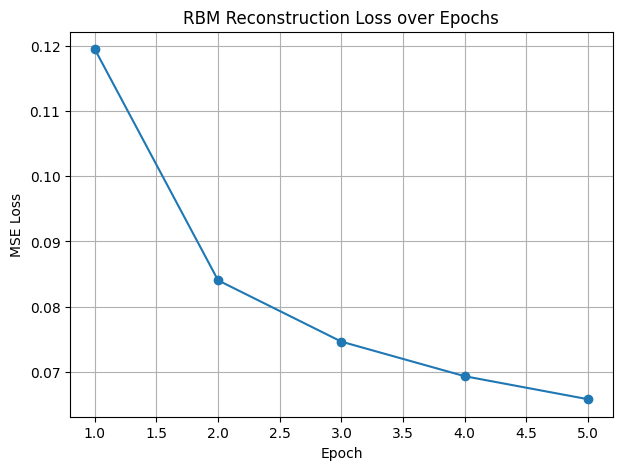

In [14]:
# 8. Implement a Restricted Boltzmann Machine (RBM) for learning binary data Representations.
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# --- Load and preprocess MNIST ---
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = (x_train > 0.5).astype('float32') # binarize
x_train = x_train.reshape(-1, 784)
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(10000).batch(batch_size)

# --- RBM Class ---
class RBM(tf.keras.Model):
    def __init__(self, n_visible, n_hidden):
        super(RBM, self).__init__()
        self.n_visible = n_visible
        self.n_hidden = n_hidden
        # Parameters
        initializer = tf.initializers.RandomNormal(mean=0.0, stddev=0.01)
        self.W = tf.Variable(initializer([n_visible, n_hidden]), name='weights')
        self.h_bias = tf.Variable(tf.zeros([n_hidden]), name='hidden_bias')
        self.v_bias = tf.Variable(tf.zeros([n_visible]), name='visible_bias')

    def sample_prob(self, probs):
        """Sample binary values from probabilities."""
        return tf.nn.relu(tf.sign(probs - tf.random.uniform(tf.shape(probs))))

    def sample_h(self, v):
        prob_h = tf.nn.sigmoid(tf.matmul(v, self.W) + self.h_bias)
        return prob_h, self.sample_prob(prob_h)

    def sample_v(self, h):
        prob_v = tf.nn.sigmoid(tf.matmul(h, tf.transpose(self.W)) + self.v_bias)
        return prob_v, self.sample_prob(prob_v)

    def contrastive_divergence(self, v, lr=0.01):
        # Positive phase
        prob_h, h0 = self.sample_h(v)
        # Negative phase (reconstruction)
        prob_v, v1 = self.sample_v(h0)
        prob_h1, _ = self.sample_h(v1)
        # Compute gradients
        positive_grad = tf.matmul(tf.transpose(v), prob_h)
        negative_grad = tf.matmul(tf.transpose(v1), prob_h1)
        # Update weights and biases
        batch_size_val = tf.cast(tf.shape(v)[0], tf.float32)
        self.W.assign_add(lr * (positive_grad - negative_grad) / batch_size_val)
        self.v_bias.assign_add(lr * tf.reduce_mean(v - v1, axis=0))
        self.h_bias.assign_add(lr * tf.reduce_mean(prob_h - prob_h1, axis=0))
        # Compute reconstruction loss (MSE)
        loss = tf.reduce_mean(tf.square(v - v1))
        return loss

# --- Initialize and train RBM ---
n_visible = 784
n_hidden = 128
rbm = RBM(n_visible, n_hidden)
n_epochs = 5
lr = 0.05
losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    for batch in train_dataset:
        loss = rbm.contrastive_divergence(batch, lr)
        epoch_loss += loss.numpy()
    avg_loss = epoch_loss / len(train_dataset)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{n_epochs}, Reconstruction Loss: {avg_loss:.4f}")

# --- Plot training loss ---
plt.figure(figsize=(7, 5))
plt.plot(range(1, n_epochs+1), losses, marker='o')
plt.title("RBM Reconstruction Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

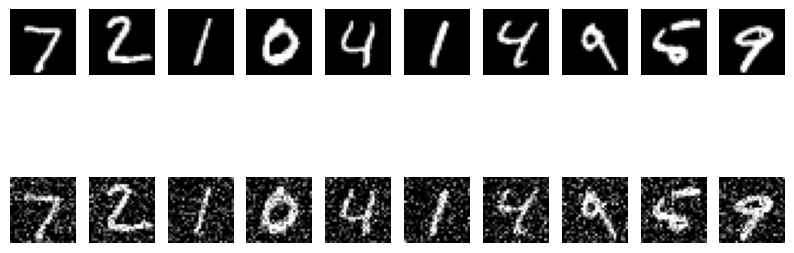

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
231/235 ━━━━━━━━━━━━━━━━━━━━ 3s 795ms/step - loss: 0.2620

KeyboardInterrupt: 

In [15]:
# 9. Develop a Denoising Autoencoder to reconstruct clean images from noisy input data.
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# Load and normalize MNIST dataset
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
x_train, x_test = np.expand_dims(x_train, -1), np.expand_dims(x_test, -1)

# Add random noise
x_train_noisy = np.clip(x_train + 0.3 * np.random.normal(0, 1, x_train.shape), 0, 1)
x_test_noisy = np.clip(x_test + 0.3 * np.random.normal(0, 1, x_test.shape), 0, 1)

# Visualize clean vs noisy images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 10, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.subplot(2, 10, i+11)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

# Build autoencoder
autoencoder = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2), padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.UpSampling2D((2,2)),
    layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')
])
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train_noisy, x_train, epochs=5, batch_size=256, validation_data=(x_test_noisy, x_test))

# Predict and visualize denoised images
decoded = autoencoder.predict(x_test_noisy)
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(3, 10, i+1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.subplot(3, 10, i+11)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.subplot(3, 10, i+21)
    plt.imshow(decoded[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.13/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Step 0 | D loss: 0.710 | G loss: 0.694


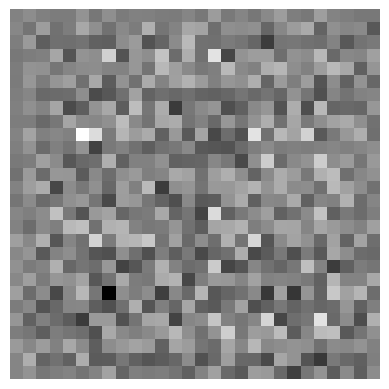

In [ ]:
# 10. Implement a simple Generative Adversarial Network (GAN) on the MNIST dataset to generate new handwritten digits.
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load and normalize MNIST
(x_train, _), _ = tf.keras.datasets.mnist.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)
batch_size = 128
buffer_size = 60000
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(buffer_size).batch(batch_size)

# Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7*7*128, input_dim=100),
        layers.LeakyReLU(0.2),
        layers.Reshape((7,7,128)),
        layers.Conv2DTranspose(64, (5,5), strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Conv2DTranspose(1, (5,5), strides=2, padding="same", activation="tanh")
    ])
    return model

# Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5,5), strides=2, padding="same", input_shape=[28,28,1]),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Conv2D(128, (5,5), strides=2, padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

# Models
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# GAN combined model
discriminator.trainable = False
gan_input = tf.keras.Input(shape=(100,))
gan_output = discriminator(generator(gan_input))
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(loss="binary_crossentropy", optimizer="adam")

# --- Training ---
epochs = 5000 # Small but enough to get clear digits
for step in range(epochs):
    # Train Discriminator
    noise = np.random.normal(0, 1, (batch_size, 100))
    fake = generator.predict(noise, verbose=0)
    real = x_train[np.random.randint(0, x_train.shape[0], batch_size)]
    X = np.concatenate([real, fake])
    y = np.concatenate([np.ones((batch_size,1)), np.zeros((batch_size,1))])
    d_loss, _ = discriminator.train_on_batch(X, y)

    # Train Generator
    noise = np.random.normal(0, 1, (batch_size, 100))
    y_gen = np.ones((batch_size,1))
    g_loss = gan.train_on_batch(noise, y_gen)

    # Print progress and save sample every 500 steps
    if step % 500 == 0:
        print(f"Step {step} | D loss: {d_loss:.3f} | G loss: {g_loss:.3f}")
        z = np.random.normal(0,1,(1,100))
        gen_img = generator.predict(z, verbose=0)[0,:,:,0]
        plt.imshow(gen_img * 0.5 + 0.5, cmap="gray")
        plt.axis("off")
        plt.show()